In [26]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\Aryavart\stock-regime-ml


In [27]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/nifty50.csv",
    parse_dates=["Date"]
)
df.head()


,Date,Open,High,Low,Close,Volume
0,2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,0
1,2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,0
2,2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,0
3,2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,0
4,2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4521 non-null   datetime64[us]
 1   Open    4521 non-null   float64       
 2   High    4521 non-null   float64       
 3   Low     4521 non-null   float64       
 4   Close   4521 non-null   float64       
 5   Volume  4521 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 212.1 KB


In [29]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [30]:
import pandas as pd
from src.labeling import (
    add_returns,
    add_volatility,
    add_volatility_regime
)

df = pd.read_csv(
    "../data/raw/nifty50.csv",
    parse_dates=["Date"]
)

df.set_index("Date", inplace=True)

df = add_returns(df)
df = add_volatility(df, window=20)
df = add_volatility_regime(df)

df.tail()

,Open,High,Low,Close,Volume,return,volatility,vol_regime
Date,,,,,,,,
2026-02-13,25571.150391,25630.349609,25444.300781,25471.099609,453500,-0.013023,0.138698,Medium
2026-02-16,25423.599609,25697.000000,25372.699219,25682.750000,275800,0.008309,0.142013,Medium
2026-02-17,25637.949219,25764.400391,25570.300781,25725.400391,344100,0.001661,0.141211,Medium
2026-02-18,25752.650391,25828.050781,25645.150391,25819.349609,310200,0.003652,0.131329,Medium
2026-02-19,25873.349609,25885.300781,25388.750000,25454.349609,0,-0.014137,0.141592,Medium


**Removed first 19 rows due to NaN values in them**

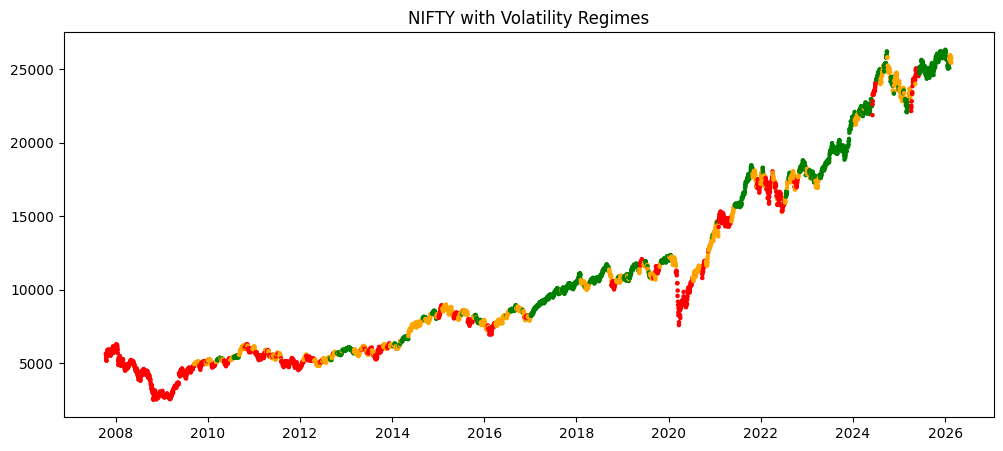

In [36]:
plot_df = df.dropna(subset=["vol_regime"])

import matplotlib.pyplot as plt

colors = {"Low": "green", "Medium": "orange", "High": "red"}

plt.figure(figsize=(12,5))
plt.scatter(
    plot_df.index,
    plot_df["Close"],
    c=plot_df["vol_regime"].map(colors),
    s=5
)
plt.title("NIFTY with Volatility Regimes")
plt.show()

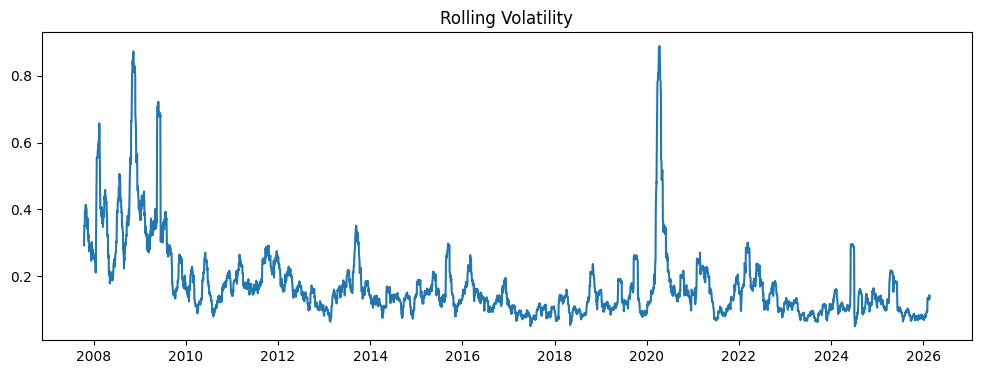

In [37]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["volatility"])
plt.title("Rolling Volatility")
plt.show()

1. ret_lag_1 → Yesterday’s move
2. ret_lag_5 → Weekly memory
3. ma_ratio_10 → Trend position
4. volatility → Current risk
5. vol_lag_1 → Regime persistence
6. target → Tomorrow’s direction

In [38]:
from src.features import (
    add_target_direction,
    add_lagged_returns,
    add_moving_average_features,
    add_volatility_features
)

df_feat = df.copy()

df_feat = add_target_direction(df_feat)
df_feat = add_lagged_returns(df_feat)
df_feat = add_moving_average_features(df_feat)
df_feat = add_volatility_features(df_feat)

df_feat.tail()

,Open,High,Low,Close,Volume,return,volatility,vol_regime,target,ret_lag_1,ret_lag_5,ret_lag_10,ma_ratio_5,ma_ratio_10,ma_ratio_20,vol_lag_1
Date,,,,,,,,,,,,,,,,
2026-02-13,25571.150391,25630.349609,25444.300781,25471.099609,453500,-0.013023,0.138698,Medium,1,-0.005650,0.001985,-0.003865,0.986987,0.991236,0.998418,0.130766
2026-02-16,25423.599609,25697.000000,25372.699219,25682.750000,275800,0.008309,0.142013,Medium,1,-0.013023,0.006757,-0.009172,0.996614,0.997166,1.006737,0.138698
2026-02-17,25637.949219,25764.400391,25570.300781,25725.400391,344100,0.001661,0.141211,Medium,1,0.008309,0.002623,0.025476,0.999897,0.998830,1.008133,0.142013
2026-02-18,25752.650391,25828.050781,25645.150391,25819.349609,310200,0.003652,0.131329,Medium,0,0.001661,0.000721,0.001883,1.004599,1.002309,1.010652,0.141211
2026-02-19,25873.349609,25885.300781,25388.750000,25454.349609,0,-0.014137,0.141592,Medium,0,0.003652,-0.005650,-0.005168,0.993124,0.988863,0.995786,0.131329


# Shifts + Rolling created missing rows
**So removed early rows (no lag) and final row (no future returns)**

In [40]:
df_feat = df_feat.dropna()

df_feat["target"].value_counts(normalize=True)

target
1    0.529556
0    0.470444
Name: proportion, dtype: float64